In [34]:
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [76]:
import torch
from torch.utils.data import DataLoader
import torchkbnufft

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [23]:
from neurorient.external.spinifel.autocorrelation import solve_ac
from neurorient.external.spinifel.phasing import phase

In [42]:
spi_data = torch.load('/pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use/PR772_neurorient_7K_iUCrJ_downsampled_128x128.pt')
spi_data.keys()

dict_keys(['orientations', 'intensities', 'pixel_position_reciprocal', 'pixel_index_map', 'volume', 'img_real_mesh', 'vol_real_mesh', 'time_stamp'])

In [172]:
from neurorient.utils_model import get_radial_profile

In [178]:
q_unique, Iq = get_radial_profile(spi_data['intensities'], spi_data['pixel_position_reciprocal'])

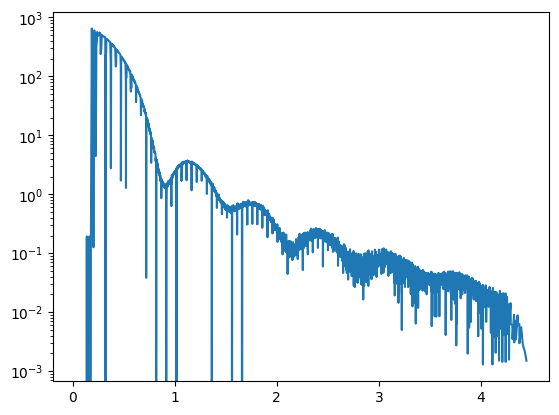

In [179]:
plt.plot(q_unique, Iq)
plt.yscale('log')

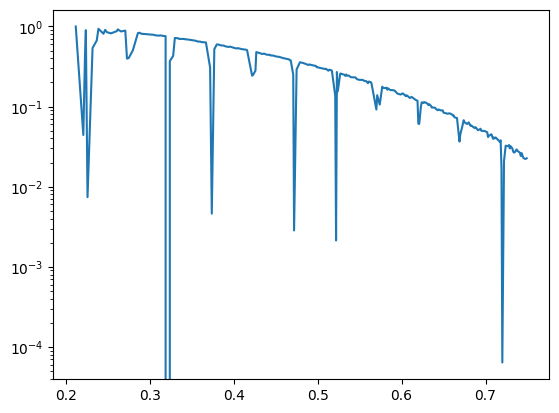

In [187]:
from scipy.optimize import curve_fit

q_mask = torch.logical_and(q_unique < .75, q_unique > .21) 
q_input = q_unique[q_mask]
Iq_input = Iq[q_mask] / Iq[q_mask].max()
plt.plot(q_input, Iq_input)
plt.yscale('log')

In [188]:
import torch

def psd_torch(q, R, a):
    """
    Returns I_psd for given q and a learnable scalar R using PyTorch tensors.
    q and R must be torch tensors.
    """
    x = q * R
    # Again, be careful if x can be near zero, but for simplicity:
    return a * ((torch.sin(x) - x * torch.cos(x)) / (x**3 + 1e-10)).pow(2)

def fit_psd_torch(q_data, I_exp_data, 
                  R_initial=300.0, 
                  a_initial=10.0,
                  learning_rate=1e-3, 
                  n_epochs=10000):
    """
    Fits the parameter R using PyTorch's autograd and an optimizer.
    q_data, I_exp_data: 1D numpy arrays or torch tensors of shape [N].
    """
    # Convert data to torch tensors if they are not already
    if not isinstance(q_data, torch.Tensor):
        q_data = torch.tensor(q_data, dtype=torch.float32)
    if not isinstance(I_exp_data, torch.Tensor):
        I_exp_data = torch.tensor(I_exp_data, dtype=torch.float32)
    
    # Initialize R as a trainable parameter
    R = torch.nn.Parameter(torch.tensor(R_initial, dtype=torch.float32))
    a = torch.nn.Parameter(torch.tensor(a_initial, dtype=torch.float32))
    
    # Define an optimizer (Adam, SGD, etc.)
    optimizer = torch.optim.Adam([R, a], lr=learning_rate)
    
    # Optimization loop
    for epoch in tqdm(range(n_epochs)):
        optimizer.zero_grad()
        
        # Forward pass: compute the model output
        I_pred = psd_torch(q_data, R, a)
        
        # Define a loss function, e.g., mean squared error
        loss = torch.mean((I_pred - I_exp_data)**2)
        
        # Backpropagation
        loss.backward()
        
        # Update R
        optimizer.step()
        
        # Optional: print progress
        # if epoch % 1000 == 0:
        #    print(f"Epoch {epoch}, Loss: {loss.item()}, R: {R.item()}")
    
    # Return the fitted value of R as a Python float
    return R.detach().item(), a.detach().item()


100%|██████████| 10000/10000 [00:04<00:00, 2271.68it/s]


Fitted R: 4.746459007263184, fitted a: 8.962965965270996


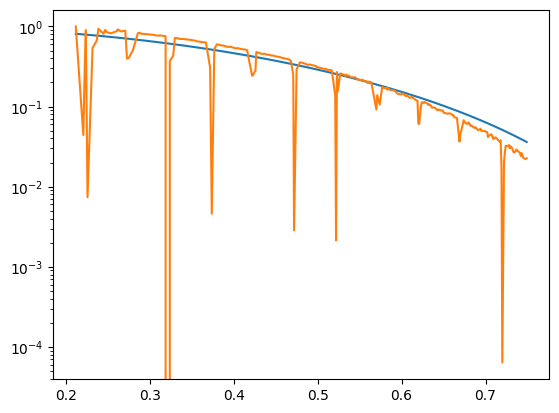

In [191]:

R_fit, a_fit = fit_psd_torch(q_input, Iq_input, 
                             R_initial=4.8, a_initial=10, n_epochs=10000, learning_rate=1e-1)
print(f"Fitted R: {R_fit}, fitted a: {a_fit}")
plt.plot(q_unique[q_mask], psd_torch(q_unique[q_mask], torch.tensor(R_fit), torch.tensor(a_fit)))
plt.plot(q_input, Iq_input)
plt.yscale('log')

In [221]:
normed_pixel_position_reciprocal = (spi_data['pixel_position_reciprocal'][0] \
    / spi_data['pixel_position_reciprocal'].max() * np.pi).norm(dim=-1)

In [224]:
spi_data['intensities'][:, ~q_filling_mask].shape

torch.Size([7303, 16328])

In [222]:
q_filling_mask = normed_pixel_position_reciprocal < q_input.min()

In [229]:
q_filling_values = psd_torch(normed_pixel_position_reciprocal[q_filling_mask], torch.tensor(R_fit), torch.tensor(a_fit))

In [230]:
intensities_filled = torch.zeros_like(spi_data['intensities'])

In [234]:
intensities_filled[:, q_filling_mask] = q_filling_values
intensities_filled[:, ~q_filling_mask] = spi_data['intensities'][:, ~q_filling_mask] / Iq[q_mask].max()

In [47]:
from neurorient.model_codebook import NeurOrientLightning

In [48]:
import os, yaml
from neurorient.utils_config import prepare_dataset
from neurorient.configurator import Configurator


In [82]:
ckpt_path = '/pscratch/sd/z/zhantao/neurorient_repo/experiments/PR772_iUCrJ_7K_downsampled_128x128/lightning_logs/version_34698696/checkpoints/PR772-epoch=174-step=5925.ckpt'

from neurorient.utils_config    import (
    prepare_Slice2RotMat_config, prepare_IntensityNet_config, prepare_optimization_config)

config_yaml = os.path.join(os.path.dirname(os.path.dirname(ckpt_path)), 'input.yaml')
print('loading model from the checkpoint: ', ckpt_path)

with open(config_yaml, 'r') as fh:
    config_dict = yaml.safe_load(fh)
CONFIG = Configurator.from_dict(config_dict)

over_sampling = CONFIG.MODEL.OVERSAMPLING
photons_per_pulse = CONFIG.DATASET.INCREASE_FACTOR * 1e12
config_optimization = prepare_optimization_config(CONFIG)
config_intensitynet = prepare_IntensityNet_config(CONFIG)
config_slice2rotmat = prepare_Slice2RotMat_config(CONFIG)

# config_slice2rotmat['point_group'] = CONFIG.MODEL.POINT_GROUP

if hasattr(CONFIG.MODEL, "PRED_PHOTON_PULSE_ANYWAY"):
    if CONFIG.MODEL.PRED_PHOTON_PULSE_ANYWAY:
        use_fluctuation_predictor=True
    else:
        use_fluctuation_predictor=False
else:
    if CONFIG.DATASET.USES_PHOTON_FLUCTUATION:
        use_fluctuation_predictor=True
    else:
        use_fluctuation_predictor=False
        

if hasattr(CONFIG.MODEL, "ROTMAT_DIVERSITY"):
    config_orientation_diversity_loss = {
        'max': CONFIG.MODEL.ROTMAT_DIVERSITY.MAX,
        'min': CONFIG.MODEL.ROTMAT_DIVERSITY.MIN,
        'scale': CONFIG.MODEL.ROTMAT_DIVERSITY.SCALE
    }
else:
    config_orientation_diversity_loss = None


model = NeurOrientLightning(
    spi_data['pixel_position_reciprocal'],
    over_sampling=over_sampling, 
    photons_per_pulse=photons_per_pulse,
    use_bifpn=CONFIG.MODEL.USE_BIFPN,
    use_fluctuation_predictor=use_fluctuation_predictor,
    config_slice2rotmat=config_slice2rotmat,
    config_intensitynet=config_intensitynet,
    config_optimization=config_optimization
)

dataset = prepare_dataset(CONFIG, spi_data['intensities'])
dataloader = DataLoader(dataset, batch_size=25, shuffle=False)

loading model from the checkpoint:  /pscratch/sd/z/zhantao/neurorient_repo/experiments/PR772_iUCrJ_7K_downsampled_128x128/lightning_logs/version_34698696/checkpoints/PR772-epoch=174-step=5925.ckpt
Initialized with 46080 reference rotations and max_val: 100.0
Reference images generated, sampling at max_val: 100.0
transformation: beam stop mask loaded from /global/homes/z/zhantao/Projects/NeuralOrientationMatching/input/PR772/beam_stop_mask_downsampled_128x128.pt.
1 transformations applied to training and validation datasets.


100%|██████████| 7303/7303 [00:01<00:00, 4930.46it/s]


created dataset with 7303 images.


In [84]:
model.load_state_dict(torch.load(ckpt_path)['state_dict'], strict=False)
model.to(device);

In [99]:
_all_orientations = []

with torch.no_grad():
    for batch in tqdm(dataloader, total=len(dataloader)):
        batch = {k: v.to(device) for k, v in batch.items()}
        _orientations, _ = model.model.estimate(batch, return_reconstruction=True)
        _all_orientations.append(_orientations.detach().cpu())
        # break

100%|██████████| 293/293 [00:19<00:00, 14.79it/s]


In [100]:
from pytorch3d.transforms import matrix_to_quaternion
all_orientations = matrix_to_quaternion(torch.vstack(_all_orientations)).numpy()

In [101]:
pixel_position_reciprocal = spi_data['pixel_position_reciprocal']
pixel_distance_reciprocal = pixel_position_reciprocal.norm(dim=-1)

In [237]:
ac = solve_ac(
    pixel_position_reciprocal.cpu().numpy(),
    pixel_distance_reciprocal.cpu().numpy(),
    # torch.fft.ifftshift(spi_data['intensities'][:], dim=(-2, -1)).cpu().numpy(),
    # spi_data['intensities'][:].cpu().numpy(),
    intensities_filled.cpu().numpy(),
    orientations=all_orientations[:]
)

##### core_problem uvect: (array([  0,   0,   0, ..., 127, 127, 127]), array([  0,   0,   0, ..., 127, 127, 127]), array([  0,   1,   2, ..., 125, 126, 127]))
##### core_problem uvect: (array([64]), array([64]), array([64]))
##### core_problem uvect: (array([64]), array([64]), array([64]))
##### core_problem uvect: (array([64]), array([64]), array([64]))
##### core_problem uvect: (array([64]), array([64]), array([64]))
##### core_problem uvect: (array([64]), array([64]), array([64]))
##### core_problem uvect: (array([64]), array([64]), array([64]))
##### core_problem uvect: (array([64]), array([64]), array([64]))
##### core_problem uvect: (array([64]), array([64]), array([64]))
##### core_problem uvect: (array([64]), array([64]), array([64]))
##### core_problem uvect: (array([64]), array([64]), array([64]))
##### core_problem uvect: (array([64]), array([64]), array([64]))
##### core_problem uvect: (array([64]), array([64]), array([64]))
##### core_problem uvect: (array([64]), array([64

In [238]:

phase_settings = {
    'nER': 50,
    'nHIO': 25,
    'N_phase_loops': 200,
    'beta': 0.8,
    'tqdm': True
}

ac_phased, support_, rho_ = phase(ac, settings=phase_settings)

100%|██████████| 200/200 [00:26<00:00,  7.63it/s]


In [239]:
intensities_ = np.fft.fftshift(np.abs(np.fft.fftn(np.fft.ifftshift(ac))))

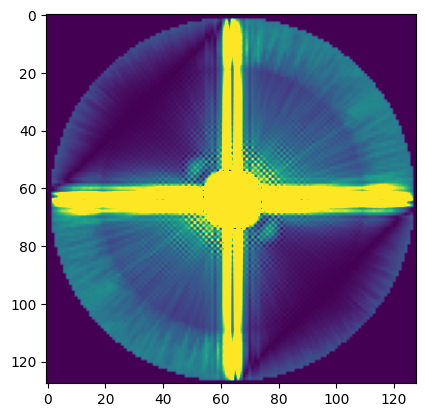

: 

In [244]:
plt.imshow(intensities_[...,64], vmax=intensities_.max()*0.01)

In [241]:
rho = np.fft.ifftshift(rho_, axes=(-3, -2, -1))

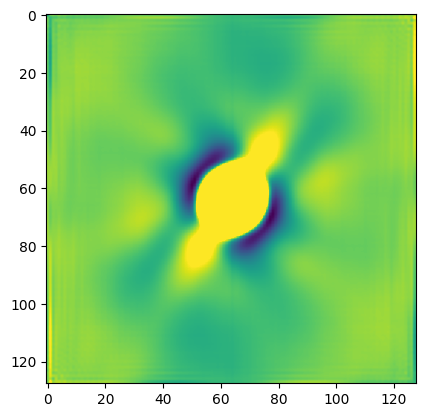

In [242]:
plt.imshow(ac[...,64], vmax=ac.max() * 0.01)

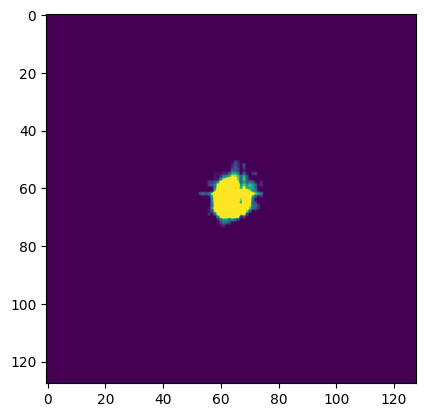

In [243]:
plt.imshow(rho[...,64], vmax=rho.max() * .25) 